In [1]:
import sys
import os

import numpy as np
import random

import torch
import torch.nn as nn
from torchinfo import summary
from torchvision.transforms import transforms
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np 
from collections import Counter

BASE_FOLDER = os.path.dirname(os.getcwd())
sys.path.append(BASE_FOLDER)

from src.models import *
from src.utils import *

In [2]:
def init(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
init()

In [4]:
DATASET_FOLDER = os.path.join(BASE_FOLDER, "data", "105_classes_pins_dataset")
CHECKPOINTS_FOLDER = os.path.join(BASE_FOLDER, "checkpoints", "recognition_4")
MODEL_NAME = "recognition_4"
EPOCHS = 200

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
ds = dict()

for name in os.listdir(DATASET_FOLDER):
    if name not in ds:
        ds[name] = []
    
    folder = os.path.join(DATASET_FOLDER, name)
     
    for f in os.listdir(folder):
        ds[name].append(f)

for k, v in ds.items():
    print(f"class: {k} | images: {len(v)}")        

class: pins_Adriana Lima | images: 213
class: pins_Alex Lawther | images: 152
class: pins_Alexandra Daddario | images: 225
class: pins_Alvaro Morte | images: 139
class: pins_alycia dabnem carey | images: 211
class: pins_Amanda Crew | images: 117
class: pins_amber heard | images: 218
class: pins_Andy Samberg | images: 196
class: pins_Anne Hathaway | images: 203
class: pins_Anthony Mackie | images: 124
class: pins_Avril Lavigne | images: 162
class: pins_barack obama | images: 119
class: pins_barbara palvin | images: 197
class: pins_Ben Affleck | images: 126
class: pins_Bill Gates | images: 122
class: pins_Bobby Morley | images: 138
class: pins_Brenton Thwaites | images: 209
class: pins_Brian J. Smith | images: 102
class: pins_Brie Larson | images: 169
class: pins_camila mendes | images: 162
class: pins_Chris Evans | images: 166
class: pins_Chris Hemsworth | images: 159
class: pins_Chris Pratt | images: 176
class: pins_Christian Bale | images: 154
class: pins_Cristiano Ronaldo | images: 9

In [6]:
# min_h, max_h = 1e6, 0
# min_w, max_w = 1e6, 0

# for k, v in ds.items():
#     for name in v:
#         path = os.path.join(DATASET_FOLDER, k, name)
#         with Image.open(path) as img:
#             w, h = img.size  

#             if h < min_h:
#                 min_h = h
#             if h > max_h:
#                 max_h = h

#             if w < min_w:
#                 min_w = w
#             if w > max_w:
#                 max_w = w

# print(f"Height: Min={min_h}, Max={max_h}")
# print(f"Width:  Min={min_w}, Max={max_w}")

In [7]:
# labels = set()
# for filename in images:
#     class_name: str = filename.split("_")[0]
#     if class_name not in labels:
#         labels.add(class_name.lower())

# with open("labels.txt", "w", encoding="utf-8") as f:
#     for name in labels:
#         f.write(name + "\n")

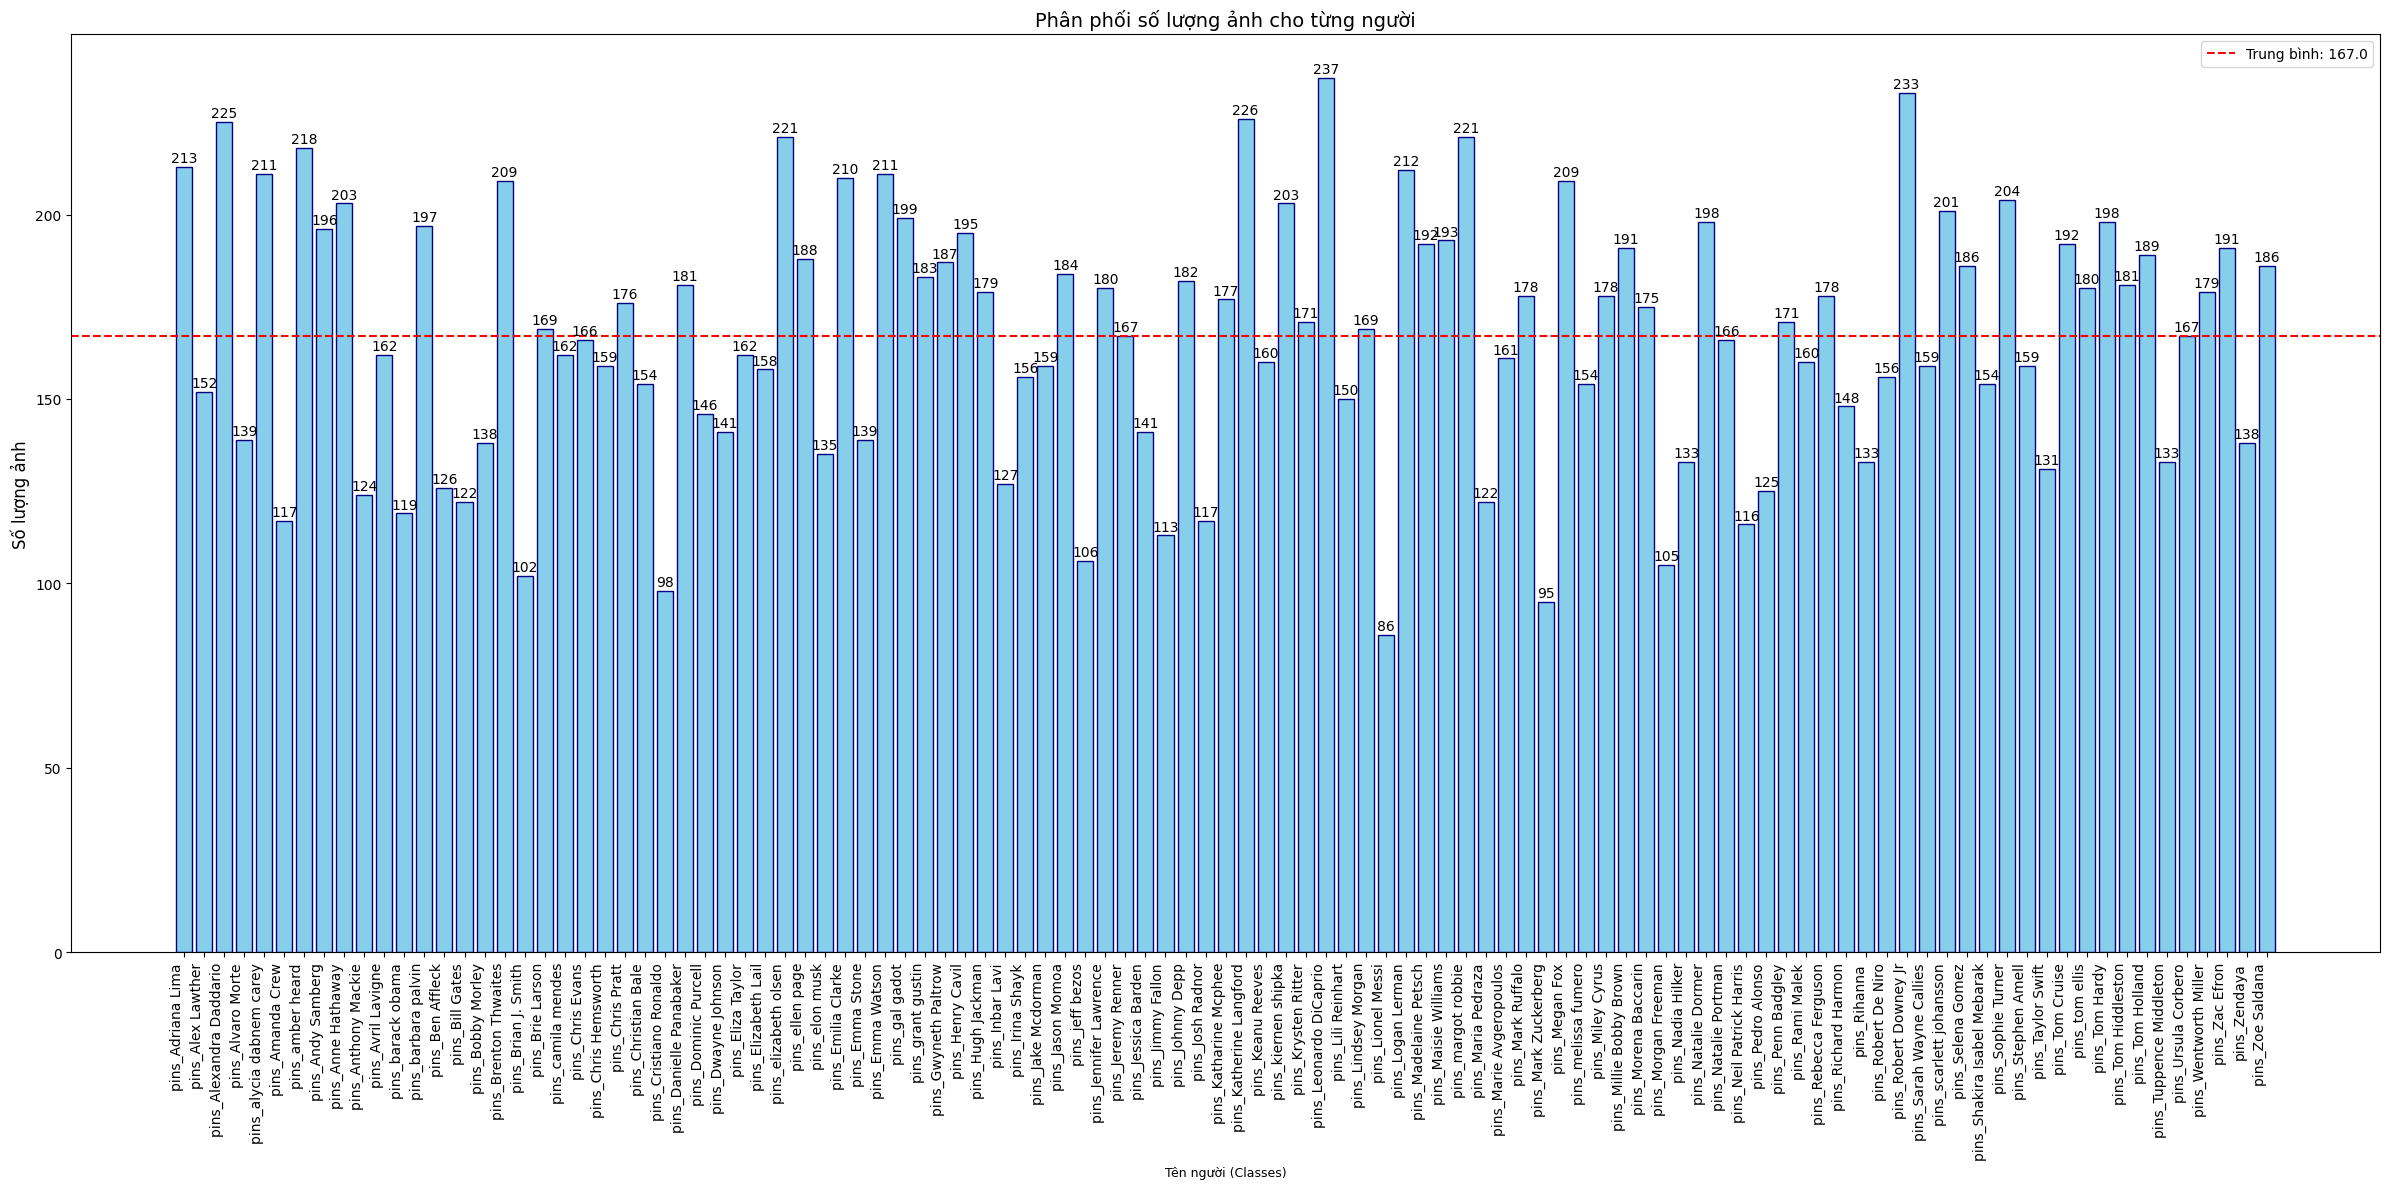

In [8]:
names = list(ds.keys())
counts = [len(files) for files in ds.values()]

plt.figure(figsize=(24, 12))
bars = plt.bar(names, counts, color="skyblue", edgecolor="navy")

plt.xlabel("Tên người (Classes)", fontsize=9)
plt.ylabel("Số lượng ảnh", fontsize=12)
plt.title("Phân phối số lượng ảnh cho từng người", fontsize=14)
plt.xticks(rotation=90, ha="right")

avg_val = sum(counts) / len(counts)
plt.axhline(avg_val, color="red", linestyle="--", label=f"Trung bình: {avg_val:.1f}")
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, yval + 0.5, yval, ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

In [9]:
variance = np.var(counts)
std_dev = np.std(counts)

print(f"Phương sai: {variance:.2f}")
print(f"Độ lệch chuẩn: {std_dev:.2f}")

Phương sai: 1153.69
Độ lệch chuẩn: 33.97


In [10]:
class_names = sorted(ds.keys())
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

In [11]:
class_to_idx

{'pins_Adriana Lima': 0,
 'pins_Alex Lawther': 1,
 'pins_Alexandra Daddario': 2,
 'pins_Alvaro Morte': 3,
 'pins_Amanda Crew': 4,
 'pins_Andy Samberg': 5,
 'pins_Anne Hathaway': 6,
 'pins_Anthony Mackie': 7,
 'pins_Avril Lavigne': 8,
 'pins_Ben Affleck': 9,
 'pins_Bill Gates': 10,
 'pins_Bobby Morley': 11,
 'pins_Brenton Thwaites': 12,
 'pins_Brian J. Smith': 13,
 'pins_Brie Larson': 14,
 'pins_Chris Evans': 15,
 'pins_Chris Hemsworth': 16,
 'pins_Chris Pratt': 17,
 'pins_Christian Bale': 18,
 'pins_Cristiano Ronaldo': 19,
 'pins_Danielle Panabaker': 20,
 'pins_Dominic Purcell': 21,
 'pins_Dwayne Johnson': 22,
 'pins_Eliza Taylor': 23,
 'pins_Elizabeth Lail': 24,
 'pins_Emilia Clarke': 25,
 'pins_Emma Stone': 26,
 'pins_Emma Watson': 27,
 'pins_Gwyneth Paltrow': 28,
 'pins_Henry Cavil': 29,
 'pins_Hugh Jackman': 30,
 'pins_Inbar Lavi': 31,
 'pins_Irina Shayk': 32,
 'pins_Jake Mcdorman': 33,
 'pins_Jason Momoa': 34,
 'pins_Jennifer Lawrence': 35,
 'pins_Jeremy Renner': 36,
 'pins_Jessic

In [12]:
train, val, test = [], [], []

for class_name, files in ds.items():
    random.shuffle(files)
    
    label = class_to_idx[class_name]

    n = len(files)
    n_train = int(0.8 * n)
    n_val = int(0.15 * n)

    for f in files[:n_train]:
        path = os.path.join(DATASET_FOLDER, class_name, f)
        train.append((path, label))
        
    for f in files[n_train : n_train + n_val]:
        path = os.path.join(DATASET_FOLDER, class_name, f)
        val.append((path, label))
        
    for f in files[n_train + n_val :]:
        path = os.path.join(DATASET_FOLDER, class_name, f)
        test.append((path, label))
        
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 13979 | Val: 2574 | Test: 981


In [13]:
# from src.utils import SquarePad

# means = []
# stds = []


# calculation_transform = transforms.Compose([
#     SquarePad(),
#     transforms.Resize((112, 112)),
#     transforms.ToTensor()
# ])


# for path, label in train:
#     image = Image.open(path).convert('RGB')
#     image = calculation_transform(image)

#     means.append(torch.mean(image, dim=(1, 2)))
#     stds.append(torch.std(image, dim=(1, 2)))

# mean = torch.mean(torch.stack(means), dim=0)
# std = torch.mean(torch.stack(stds), dim=0)

# print(f"Mean: {mean}")
# print(f"Std:  {std}")

In [14]:
mean = [0.4842, 0.3931, 0.3500]

In [15]:
std = [0.2785, 0.2443, 0.2282]

In [16]:
train_transform = transforms.Compose(
    [
        SquarePad(),
        transforms.Resize((112, 112)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=mean, std=std
        ),
    ]
)

valid_transform = transforms.Compose(
    [
        SquarePad(),
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=mean, std=std
        ),
    ]
)

In [17]:
train_ds = RecognitionDataset(
    data_list=train, transform=train_transform
)
val_ds = RecognitionDataset(
    data_list=val, transform=valid_transform
)
test_ds = RecognitionDataset(
    data_list=test, transform=valid_transform
)

In [18]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    dataset=val_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

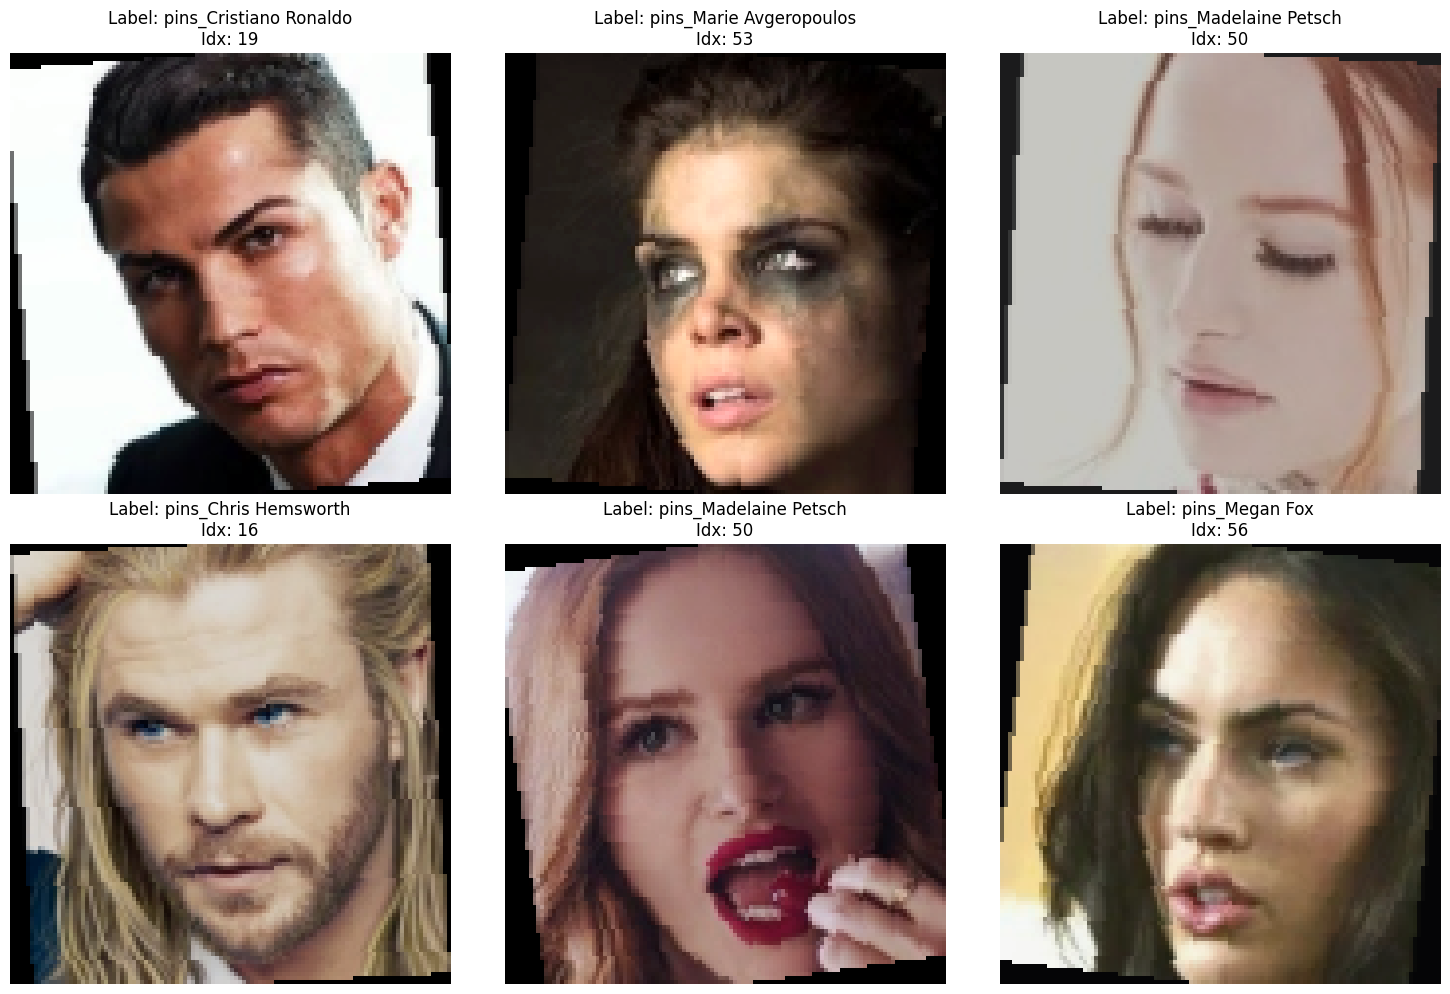

In [19]:
ds_iter = iter(train_loader)
ds_images, ds_labels = next(ds_iter)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

img_mean = np.array(mean)
img_std = np.array(std)

for i in range(6):
    image = ds_images[i].permute(1, 2, 0).cpu().numpy()
    label_idx = ds_labels[i].item()
    
    image = image * img_std + img_mean
    image = np.clip(image, 0, 1)
    
    axes[i].imshow(image)
    axes[i].set_title(f"Label: {class_names[label_idx]}\nIdx: {label_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [20]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device,
):
    history = []
    excel = os.path.join(CHECKPOINTS_FOLDER, f"{MODEL_NAME}_logs.xlsx")

    main_loop = tqdm(range(epochs), desc="Training Progress")

    for epoch in main_loop:
        model.train()
        train_loss, train_correct = 0.0, 0

        train_pbar = tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False
        )
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)

            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct.double().item() / len(train_loader.dataset)

        model.eval()
        val_loss, val_correct = 0.0, 0
        all_preds, all_labels = [], []

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                val_pbar.set_postfix(v_loss=f"{loss.item():.4f}")

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct.double().item() / len(val_loader.dataset)

        metrics = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc": avg_train_acc,
            "val_loss": avg_val_loss,
            "val_acc": avg_val_acc,
            "val_f1": f1_score(all_labels, all_preds, average="weighted"),
            "val_precision": precision_score(
                all_labels, all_preds, average="weighted", zero_division=0
            ),
            "val_recall": recall_score(all_labels, all_preds, average="weighted"),
        }
        history.append(metrics)

        main_loop.set_postfix(
            {
                "T-Loss": f"{avg_train_loss:.3f}",
                "T-Acc": f"{avg_train_acc:.3f}",
                "V-Loss": f"{avg_val_loss:.3f}",
                "V-Acc": f"{avg_val_acc:.3f}",
            }
        )

        pd.DataFrame(history).to_excel(excel, index=False)
        torch.save(
            model.state_dict(),
            os.path.join(CHECKPOINTS_FOLDER, f"{MODEL_NAME}_{epoch}.pth"),
        )

    return history

In [21]:
model = MyRecognitionModel(num_classes=len(ds.keys()))
summary(
    model,
    input_size=(1, 3, 112, 112),
)
model.to(device)

MyRecognitionModel(
  (block1): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
   

In [22]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

In [23]:
fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
)

Training Progress: 100%|██████████| 200/200 [54:02<00:00, 16.21s/it, T-Loss=1.160, T-Acc=0.967, V-Loss=1.362, V-Acc=0.878]


[{'epoch': 1,
  'train_loss': 4.726549998196688,
  'train_acc': 0.01337720867014808,
  'val_loss': 4.543711548759823,
  'val_acc': 0.034576534576534576,
  'val_f1': 0.012831107506979288,
  'val_precision': 0.012104926658127194,
  'val_recall': 0.034576534576534576},
 {'epoch': 2,
  'train_loss': 4.613771889426491,
  'train_acc': 0.024036054081121683,
  'val_loss': 4.484280063992455,
  'val_acc': 0.03496503496503497,
  'val_f1': 0.013436909973968859,
  'val_precision': 0.01192763412622949,
  'val_recall': 0.03496503496503497},
 {'epoch': 3,
  'train_loss': 4.551266856627031,
  'train_acc': 0.027898991344159095,
  'val_loss': 4.435034116109212,
  'val_acc': 0.04623154623154623,
  'val_f1': 0.022045895651800273,
  'val_precision': 0.02384531713915537,
  'val_recall': 0.04623154623154623},
 {'epoch': 4,
  'train_loss': 4.49622859954834,
  'train_acc': 0.033693397238715214,
  'val_loss': 4.358286812191918,
  'val_acc': 0.05244755244755245,
  'val_f1': 0.02515058189704569,
  'val_precision':

In [24]:
def evaluate(model, test_loader, class_names, log_path, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    test_acc = accuracy_score(y_true, y_pred)
    print(f"Test accuracy: {test_acc:.2%}")

    df = pd.read_csv(log_path) if log_path.endswith(".csv") else pd.read_excel(log_path)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(
        df["epoch"], df["train_acc"], label="Train Acc", color="#1f77b4", linewidth=2
    )
    plt.plot(df["epoch"], df["val_acc"], label="Val Acc", color="#ff7f0e", linewidth=2)
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Acc")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss", color="#d62728")
    plt.plot(df["epoch"], df["val_loss"], label="Val Loss", color="#2ca02c")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    num_display = 30
    cm = confusion_matrix(y_true, y_pred)
    cm_display = cm[:num_display, :num_display]

    plt.imshow(cm_display, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Top {num_display})")
    plt.colorbar()

    tick_marks = np.arange(num_display)
    plt.xticks(tick_marks, class_names[:num_display], rotation=90, fontsize=8)
    plt.yticks(tick_marks, class_names[:num_display], fontsize=8)

    plt.ylabel("Real")
    plt.xlabel("Pred")

    plt.tight_layout()
    plt.show()

Test accuracy: 88.07%


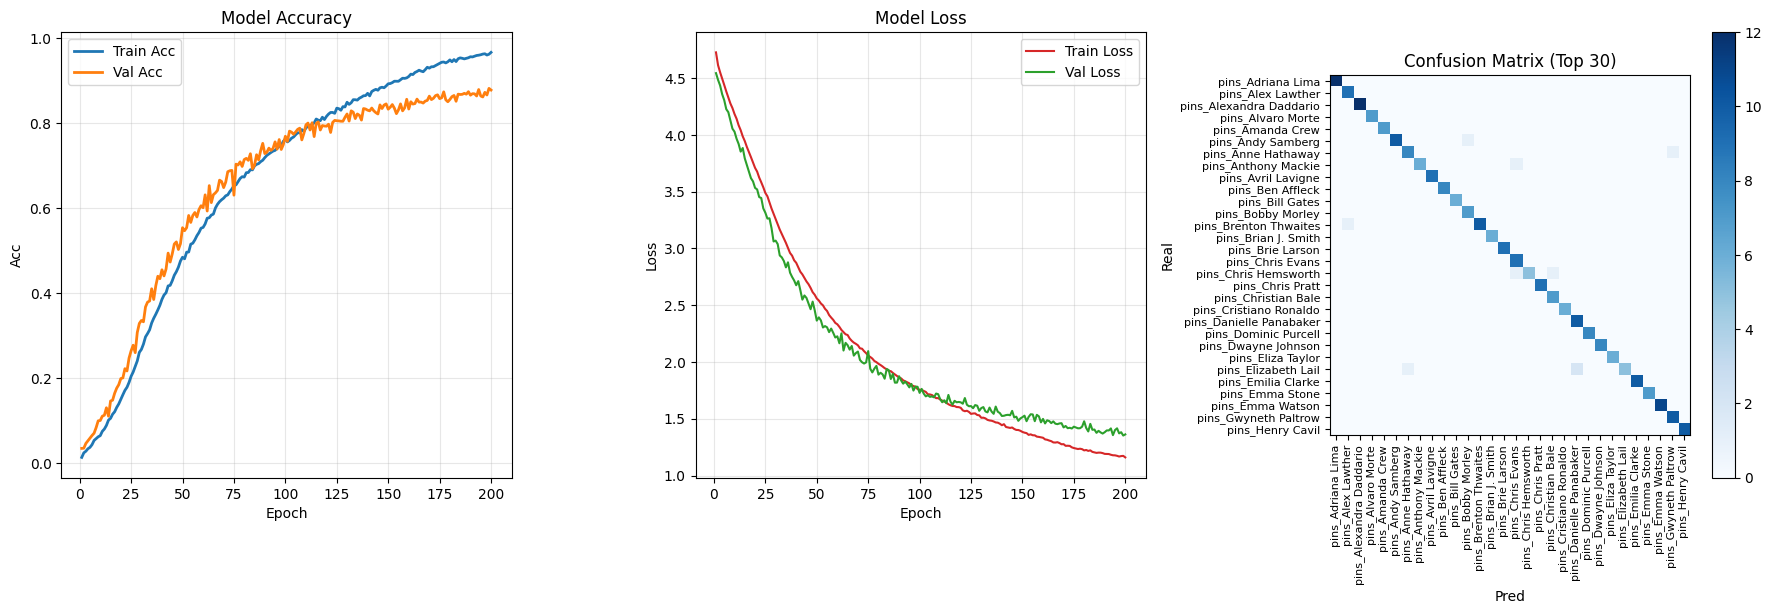

In [25]:
evaluate(model, test_loader, class_names, os.path.join(CHECKPOINTS_FOLDER,f"{MODEL_NAME}_logs.xlsx"), device)